# Generative Adversarial Networks

Replication of Goodfellow, Pouget-Abadie, Mirza, Xu, Warde-Farley, Ozair, Courville and
Bengio (2014), *Generative Adversarial Nets*, NeurIPS.

We set up the original adversarial game between a generator G and a discriminator D, both
multilayer perceptrons, and train them on MNIST with the minimax objective (using the
non-saturating generator loss recommended in the paper). After training, G maps random
noise to recognizable handwritten digits.

In [1]:
import torch, torch.nn as nn
import torchvision as tv, torchvision.transforms as T
import matplotlib.pyplot as plt
torch.manual_seed(0)
ZDIM = 64

In [2]:
tf = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])   # scale pixels to [-1, 1]
train = tv.datasets.MNIST("../data", train=True, download=True, transform=tf)
train_dl = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True, drop_last=True)
print("train", len(train))

train 60000


In [3]:
G = nn.Sequential(
    nn.Linear(ZDIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),  nn.LeakyReLU(0.2),
    nn.Linear(512, 784),  nn.Tanh())                 # output in [-1, 1] like the data
D = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),   nn.Sigmoid())
print("G params", sum(p.numel() for p in G.parameters()), "| D params", sum(p.numel() for p in D.parameters()))

G params 550416 | D params 533505


In [4]:
bce = nn.BCELoss()
optG = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optD = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

EPOCHS = 25
for ep in range(EPOCHS):
    for x, _ in train_dl:
        bs = x.size(0)
        real, fake = torch.ones(bs, 1), torch.zeros(bs, 1)
        # train D: real should -> 1, generated should -> 0
        z = torch.randn(bs, ZDIM); gen = G(z)
        lossD = bce(D(x), real) + bce(D(gen.detach()), fake)
        optD.zero_grad(); lossD.backward(); optD.step()
        # train G: push generated samples toward D output 1 (non-saturating loss)
        lossG = bce(D(gen), real)
        optG.zero_grad(); lossG.backward(); optG.step()
    if (ep+1) % 5 == 0 or ep == 0:
        print(f"epoch {ep+1:2d}: lossD={lossD.item():.3f} lossG={lossG.item():.3f}")

epoch  1: lossD=0.551 lossG=2.139


epoch  5: lossD=0.515 lossG=1.682


epoch 10: lossD=0.546 lossG=3.615


epoch 15: lossD=0.820 lossG=1.149


epoch 20: lossD=0.929 lossG=1.114


epoch 25: lossD=1.105 lossG=1.048


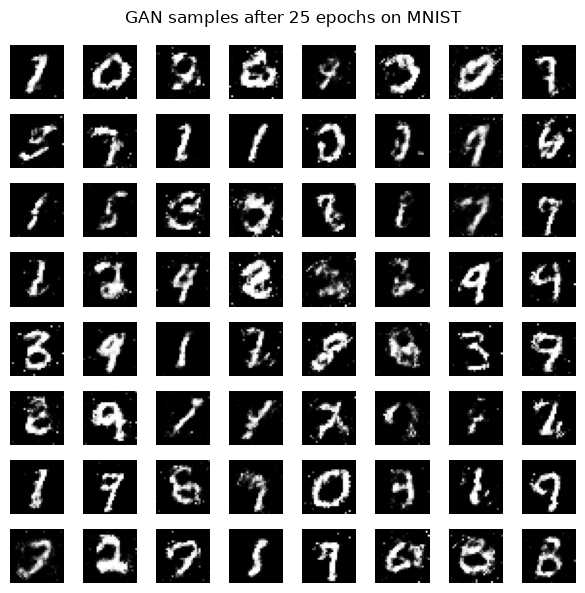

In [5]:
# Sample a grid of digits from the trained generator.
G.eval()
with torch.no_grad():
    samples = G(torch.randn(64, ZDIM)).view(-1, 28, 28)
fig, ax = plt.subplots(8, 8, figsize=(6, 6))
for i, a in enumerate(ax.flat):
    a.imshow(samples[i], cmap="gray"); a.axis("off")
plt.suptitle("GAN samples after 25 epochs on MNIST"); plt.tight_layout(); plt.show()